In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("countries of the world.csv",decimal=',')
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [16]:
data = df.iloc[:,7:17].copy()
data.drop(columns=['Arable (%)', 'Crops (%)', 'Other (%)', 'Climate'], inplace=True)
data_clean = data.dropna()
data_clean.info()
data_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 203 entries, 0 to 226
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Infant mortality (per 1000 births)  203 non-null    float64
 1   GDP ($ per capita)                  203 non-null    float64
 2   Literacy (%)                        203 non-null    float64
 3   Phones (per 1000)                   203 non-null    float64
 4   Birthrate                           203 non-null    float64
 5   Deathrate                           203 non-null    float64
dtypes: float64(6)
memory usage: 11.1 KB


,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Birthrate,Deathrate
0,163.07,700.0,36.0,3.2,46.60,20.34
1,21.52,4500.0,86.5,71.2,15.11,5.22
2,31.00,6000.0,70.0,78.1,17.14,4.61
3,9.27,8000.0,97.0,259.5,22.46,3.27
4,4.05,19000.0,100.0,497.2,8.71,6.25


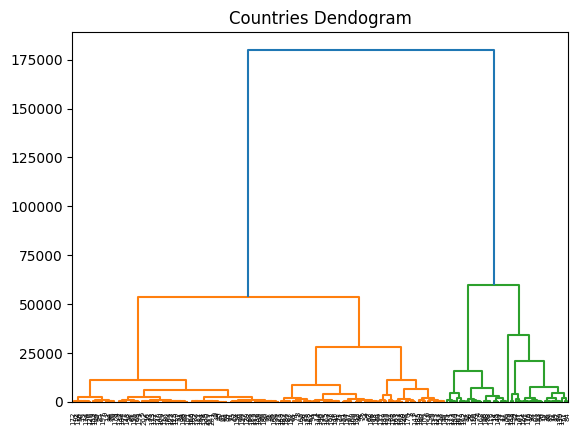

In [15]:
import scipy.cluster.hierarchy as shc
plt.title('Countries Dendogram')
dend=shc.dendrogram(shc.linkage(data_clean,method='ward'))

In [44]:
from sklearn.cluster import AgglomerativeClustering
agc = AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
labels = agc.fit_predict(data_clean)
labels


array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1])

In [45]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(data_clean, labels)  # Higher = better
db_score = davies_bouldin_score(data_clean, labels)  # Lower = better  
ch_score = calinski_harabasz_score(data_clean, labels)  # Higher = better

print(f"Silhouette: {sil_score:.3f}")
print(f"Davies-Bouldin: {db_score:.3f}")
print(f"Calinski-Harabasz: {ch_score:.1f}")


# Silhouette	    >0.5	0.4-0.6 typical for country data 
# Davies-Bouldin	<1.0	<1.5 acceptable
# Calinski-Harabasz	>100	Depends on n_samples (~150 for countries)


Silhouette: 0.730
Davies-Bouldin: 0.435
Calinski-Harabasz: 669.6
